In [27]:
import pandas as pd 
from sklearn import datasets
df = pd.read_csv("diabetes_prediction_dataset.csv.zip")
df.shape
df.info


<bound method DataFrame.info of        gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0              

In [28]:
# we need to encode categorial variables
df = pd.get_dummies(
    df,
    columns=['gender', 'smoking_history'],
    dtype=int
)

df

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,80.0,0,0,27.32,6.2,90,0,1,0,0,1,0,0,0,0,0
99996,2.0,0,0,17.37,6.5,100,0,1,0,0,1,0,0,0,0,0
99997,66.0,0,0,27.83,5.7,155,0,0,1,0,0,0,0,1,0,0
99998,24.0,0,0,35.42,4.0,100,0,1,0,0,0,0,0,0,1,0


In [29]:
# spliting the data 
from sklearn.model_selection import train_test_split

X = df.drop(columns="diabetes")
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 80000 samples
Testing set: 20000 samples


In [30]:
# standarization

X_train = (X_train - X_train.mean()) / X_train.std()
X_test = (X_test - X_train.mean()) / X_train.std()


In [36]:
X_train

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
74736,1.691059,3.515982,-0.20279,0.000472,0.908243,0.170206,0.842038,-0.841691,-0.014143,-0.745505,-0.320281,-0.203591,3.102265,-0.735449,-0.263174
36589,-1.016454,-0.284412,-0.20279,-0.321770,-0.959674,-0.297056,0.842038,-0.841691,-0.014143,-0.745505,-0.320281,-0.203591,-0.322341,1.359697,-0.263174
37414,-0.261901,-0.284412,-0.20279,-0.205823,1.001639,1.522806,0.842038,-0.841691,-0.014143,1.341356,-0.320281,-0.203591,-0.322341,-0.735449,-0.263174
71251,-0.306286,-0.284412,-0.20279,-0.585285,0.441264,0.514504,0.842038,-0.841691,-0.014143,-0.745505,3.122216,-0.203591,-0.322341,-0.735449,-0.263174
40454,-0.528214,-0.284412,-0.20279,-0.707255,-0.492695,-1.182394,0.842038,-0.841691,-0.014143,1.341356,-0.320281,-0.203591,-0.322341,-0.735449,-0.263174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17083,-0.128744,-0.284412,-0.20279,0.747350,-0.679486,-0.198685,0.842038,-0.841691,-0.014143,-0.745505,-0.320281,-0.203591,-0.322341,1.359697,-0.263174
27250,0.048797,-0.284412,-0.20279,0.000472,0.628056,0.489911,-1.187580,1.188070,-0.014143,-0.745505,-0.320281,-0.203591,-0.322341,1.359697,-0.263174
33409,0.448266,3.515982,-0.20279,0.000472,0.254472,0.416133,0.842038,-0.841691,-0.014143,-0.745505,-0.320281,-0.203591,3.102265,-0.735449,-0.263174
91639,-1.637850,-0.284412,-0.20279,-1.752282,0.628056,0.416133,0.842038,-0.841691,-0.014143,1.341356,-0.320281,-0.203591,-0.322341,-0.735449,-0.263174


In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Recreate the data split
X = df.drop(columns="diabetes")
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Correct scaling: fit only on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ordinary linear regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)

# L2-regularized regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)

# Compare models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge (L2)"],
    "R2": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, ridge_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, ridge_pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, linear_pred) ** 0.5,
        mean_squared_error(y_test, ridge_pred) ** 0.5
    ]
})

comparison

,Model,R2,MAE,RMSE
0,Linear Regression,0.351826,0.153868,0.224526
1,Ridge (L2),0.351826,0.153868,0.224526


Optimal penalty parameter λ: 24.420531
Cross-validated score: -0.050699


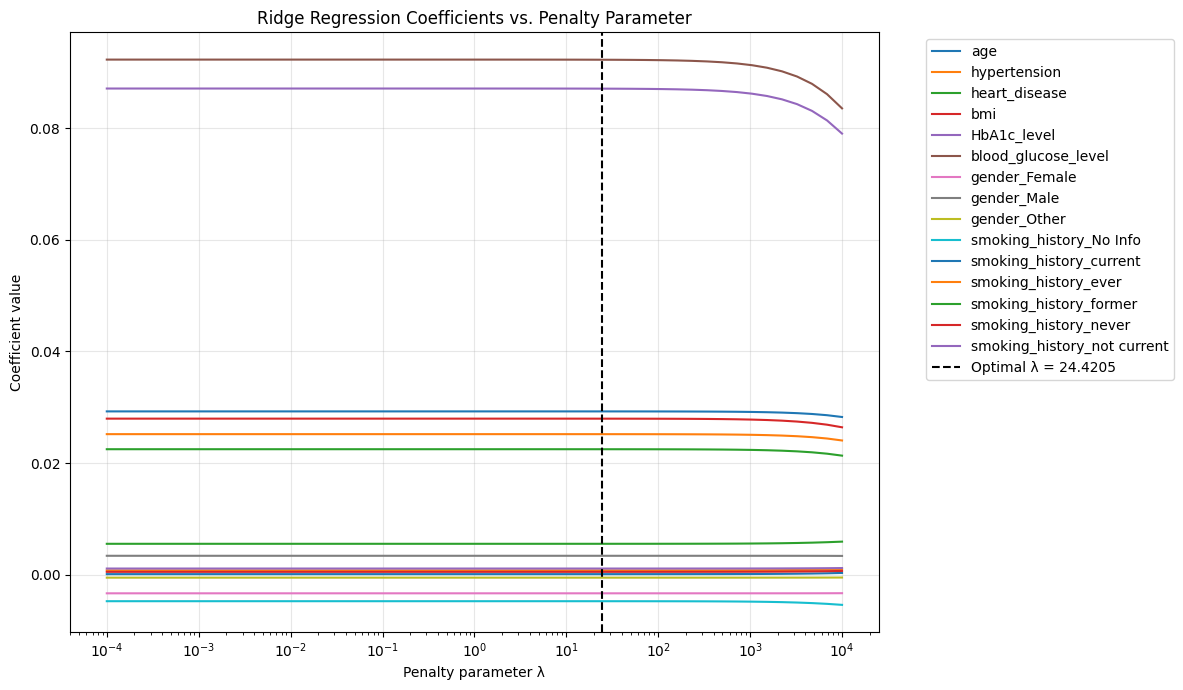


Interpretation:
- Increasing λ shrinks the coefficients toward zero.
- The selected λ provides the best cross-validated trade-off between fit and regularization.
- Features with larger absolute coefficients have greater influence on the prediction.


In [42]:
import numpy as np
from sklearn.linear_model import RidgeCV

import matplotlib.pyplot as plt

# Candidate penalty values (lambda / alpha)
alphas = np.logspace(-4, 4, 50)

# Select the optimal alpha using 5-fold cross-validation
ridge_cv_model = RidgeCV(
    alphas=alphas,
    cv=5,
    scoring="neg_mean_squared_error"
)
ridge_cv_model.fit(X_train_scaled, y_train)

print(f"Optimal penalty parameter λ: {ridge_cv_model.alpha_:.6f}")
print(f"Cross-validated score: {ridge_cv_model.best_score_:.6f}")

# Fit Ridge models for each lambda to obtain coefficient paths
coefficient_paths = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    coefficient_paths.append(model.coef_)

coefficient_paths = np.array(coefficient_paths)

# Plot coefficient values versus lambda
plt.figure(figsize=(12, 7))

for i, feature in enumerate(X_train.columns):
    plt.plot(alphas, coefficient_paths[:, i], label=feature)

plt.axvline(
    ridge_cv_model.alpha_,
    color="black",
    linestyle="--",
    label=f"Optimal λ = {ridge_cv_model.alpha_:.4f}"
)

plt.xscale("log")
plt.xlabel("Penalty parameter λ")
plt.ylabel("Coefficient value")
plt.title("Ridge Regression Coefficients vs. Penalty Parameter")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Evaluate the selected RidgeCV model
ridge_cv_pred = ridge_cv_model.predict(X_test_scaled)

print("\nInterpretation:")
print("- Increasing λ shrinks the coefficients toward zero.")
print("- The selected λ provides the best cross-validated trade-off between fit and regularization.")
print("- Features with larger absolute coefficients have greater influence on the prediction.")

Optimal penalty alpha: 0.000450
Coefficients reduced exactly to zero: 4

Selected predictors:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'smoking_history_No Info', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_not current']


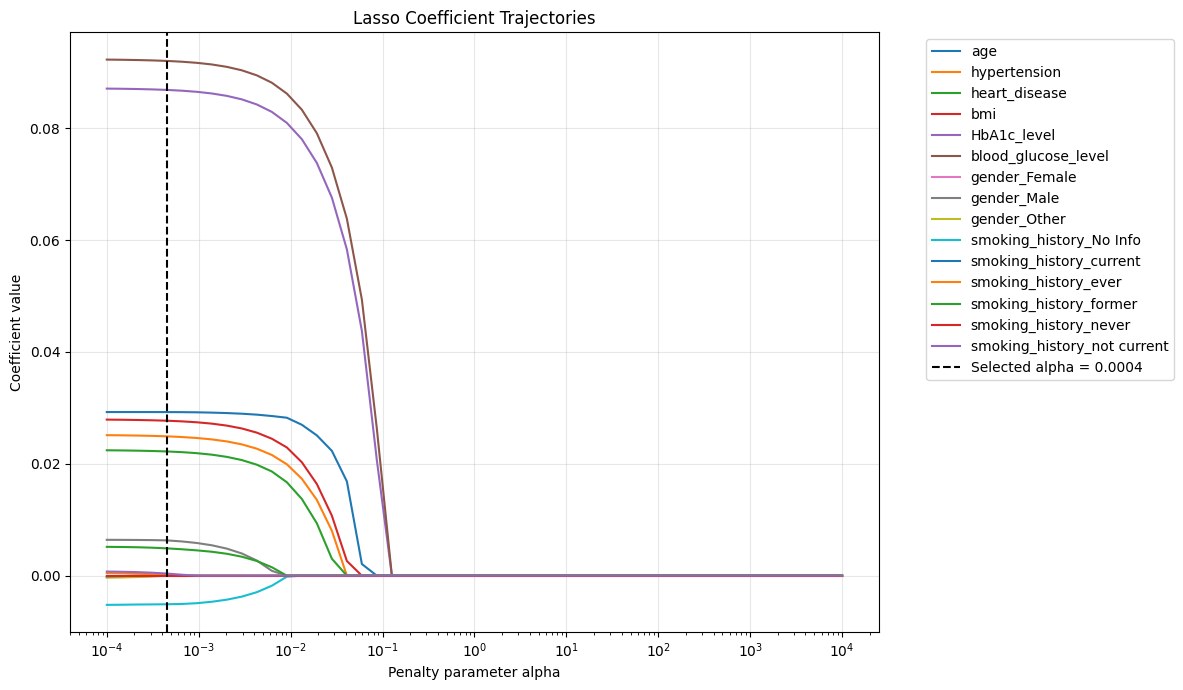


Most robust predictors:


HbA1c_level                    0.086851
blood_glucose_level            0.086851
age                            0.059636
bmi                            0.040949
hypertension                   0.028118
heart_disease                  0.028118
smoking_history_No Info        0.009103
smoking_history_former         0.006251
gender_Male                    0.006251
smoking_history_not current    0.000655
smoking_history_ever           0.000450
gender_Female                  0.000309
gender_Other                   0.000309
smoking_history_current        0.000212
smoking_history_never          0.000000
Name: largest_nonzero_alpha, dtype: float64

In [43]:
from sklearn.linear_model import LassoCV, lasso_path

# Fit Lasso with cross-validation
lasso_cv_model = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=10000,
    random_state=42
)
lasso_cv_model.fit(X_train_scaled, y_train)

lasso_coef = lasso_cv_model.coef_
zero_count = np.sum(lasso_coef == 0)

print(f"Optimal penalty alpha: {lasso_cv_model.alpha_:.6f}")
print(f"Coefficients reduced exactly to zero: {zero_count}")
print("\nSelected predictors:")
print(X_train.columns[lasso_coef != 0].tolist())

# Compute coefficient trajectories
path_alphas, path_coefs, _ = lasso_path(
    X_train_scaled,
    y_train,
    alphas=alphas,
    max_iter=10000
)

# Reverse arrays so penalty increases from left to right
order = np.argsort(path_alphas)
plot_alphas = path_alphas[order]
plot_coefs = path_coefs[:, order]

plt.figure(figsize=(12, 7))

for i, feature in enumerate(X_train.columns):
    plt.plot(plot_alphas, plot_coefs[i], label=feature)

plt.axvline(
    lasso_cv_model.alpha_,
    color="black",
    linestyle="--",
    label=f"Selected alpha = {lasso_cv_model.alpha_:.4f}"
)

plt.xscale("log")
plt.xlabel("Penalty parameter alpha")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Trajectories")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Robustness: largest penalty at which each predictor remains non-zero
tolerance = 1e-8
last_nonzero_alpha = {}

for i, feature in enumerate(X_train.columns):
    nonzero = np.abs(plot_coefs[i]) > tolerance
    last_nonzero_alpha[feature] = (
        plot_alphas[nonzero].max() if nonzero.any() else 0
    )

robust_predictors = (
    pd.Series(last_nonzero_alpha)
    .sort_values(ascending=False)
    .rename("largest_nonzero_alpha")
)

print("\nMost robust predictors:")
display(robust_predictors)

In [44]:
# Generate predictions on the test set
ols_pred = linear_model.predict(X_test_scaled)
ridge_pred = ridge_model.predict(X_test_scaled)
lasso_pred = lasso_cv_model.predict(X_test_scaled)

# Calculate evaluation metrics
results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "RMSE": [
        mean_squared_error(y_test, ols_pred) ** 0.5,
        mean_squared_error(y_test, ridge_pred) ** 0.5,
        mean_squared_error(y_test, lasso_pred) ** 0.5
    ],
    "R-Squared": [
        r2_score(y_test, ols_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})

results.sort_values("RMSE")

,Model,RMSE,R-Squared
2,Lasso,0.224515,0.351886
1,Ridge,0.224526,0.351826
0,OLS,0.224526,0.351826
